# Load & Parse Data

In [1]:
import importlib
import utils.parse_data  

importlib.reload(utils.parse_data)

/home/ab126/programs/micromamba/envs/fmri311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'utils.parse_data' from '/home/ab126/projects/fmri_connectivity/fmri_forecasting/utils/parse_data.py'>

In [2]:
from utils.parse_data import parse_dataset
from pathlib import Path

data_path = Path('../data/pooled_stratified_share_vc')
X_train, Y_train, X_test, Y_test, device = parse_dataset(root_dir=data_path, M=50, H=3, normalize=True, stride=1, test_ratio=0.2,
                                                         test_subjects=None, random_state=42, verbose=True)

Using dataset path: ../data/pooled_stratified_share_vc
Loading dataset with fixed schema settings...
Scanning and loading dataset (optimized fixed schema mode)...
Loaded: 2880 runs from 8 subjects
Subjects: ['subjA2s60K-Hhm', 'subjOenz4SHyaO', 'subjQX6R7rImeb', 'subjoVC0sHUB_P', 'subjqFdsBbuiHF', 'subjsRowSC6dc4', 'subjtySNgRhV65', 'subjxpYwO4azeZ']
Successfully loaded runs: 2880
Loading time: 9.82 seconds
Device: cuda
Normalizing dataset...
Building sliding windows...
Splitting by subject...
Train subjects: ['subjoVC0sHUB_P', 'subjqFdsBbuiHF', 'subjQX6R7rImeb', 'subjxpYwO4azeZ', 'subjtySNgRhV65', 'subjOenz4SHyaO']
Test subjects : ['subjsRowSC6dc4', 'subjA2s60K-Hhm']
Train runs: 2144
Test runs : 736
Final shapes - Train: (373056, 50, 23), (373056, 3, 23) | Test: (128064, 50, 23), (128064, 3, 23)


In [9]:
from models.transformer.transformer_api_library import transformer_model_generator, TransformerPredictorAPI

# Build transformer

model = transformer_model_generator(
    n_roi=X_train.shape[2],
    M=50,
    H=3,
    d_model=64,
    nhead=4,
    num_layers=2,
    dropout=0.1,
)

model = model.to(device)

### Read the Model

In [3]:
import torch
from pathlib import Path

from utils.validation import load_model_from_weights_save
from models.transformer.transformer_api_library import transformer_model_generator

weights_path = Path("saves") / "trained_model_weights" / "transformer_final_vc.pt"
model = load_model_from_weights_save(weights_path)
model.eval()

/home/ab126/projects/fmri_connectivity/fmri_forecasting/utils/validation.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  obj = torch.load(weights_path, map_location="cp

TransformerForecastModel(
  (input_proj): Linear(in_features=23, out_features=64, bias=True)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (output_layer): Linear(in_features=64, out_features=69, bias=True)
)

In [ ]:
from utils.training import train_forecasting_model

# Train Model
model = train_forecasting_model(
    model,
    X_train,
    Y_train,
    X_val=X_test,
    Y_val=Y_test,
    batch_size=512,
    num_epochs=50,
    device=device,
)

  Epoch  1 | train: 0.243269 | val: 0.213274


  Epoch  2 | train: 0.226014 | val: 0.210581


  Epoch  3 | train: 0.221631 | val: 0.209422


  Epoch  4 | train: 0.218738 | val: 0.209269


  Epoch  5 | train: 0.216430 | val: 0.209794
  No improvement (1/5)
  Best val loss: 0.209269 | weights restored


In [42]:
import numpy as np

X = np.concatenate([X_train, X_test], axis=0)
Y = np.concatenate([Y_train, Y_test], axis=0)

Histogram Method

In [55]:
from utils.measures import fit_histogram_proba_adapter

# Wrap with API
config = {
    "window_size": 50,
    "predict_step": 3,
    "output_horizon": 3,
    "input_dim": X_train.shape[2],
    "d_model": 64,
    "nhead": 4,
    "num_layers": 2,
    "dropout": 0.1,
}

model_api = TransformerPredictorAPI(
    model=model,
    config=config,
    stats={},
    device=device,
)

# Build histogram likelihood adapter
di_model = fit_histogram_proba_adapter(
    base_model=model_api,
    X_calib=X,
    Y_calib=Y,
    n_bins=50,
    flatten_input=False,
)

Neural Network Method

In [44]:
from utils.measures import FlowPredictorAPI

di_model = FlowPredictorAPI(
    model_obj=model,
    device=device,
)

di_model.fit_residual_std(
    X_calib=X,
    Y_calib=Y,
    batch_size=512,
)

In [43]:
import importlib
import utils.measures  

importlib.reload(utils.measures)

<module 'utils.measures' from '/home/ab126/projects/fmri_connectivity/fmri_forecasting/utils/measures.py'>

In [57]:
from utils.measures import compute_di_from_log_prob_api

reduction_mode="zero" # zero shuffle
DI_flow = compute_di_from_log_prob_api(
    model=di_model,
    X=X,
    Y=Y,
    horizon_idx=0,
    reduction_mode=reduction_mode,
)

Computing DI: 100%|██████████| 529/529 [05:41<00:00,  1.55it/s]


In [51]:
from utils.measures import make_reduced_input
import numpy as np

R = X_test.shape[2]
for i in range(5):
    X_red = make_reduced_input(X, source_roi=i, mode=reduction_mode)
    pred_full = di_model.predict(X)
    pred_red = di_model.predict(X_red)

    delta = np.mean(np.abs(pred_full - pred_red), axis=(0, 1))
    print(i, delta)

0 [0.52376956 0.04213888 0.0722006  0.04447552 0.05380813 0.04758447
 0.04350735 0.05256556 0.05299747 0.04441048 0.04379006 0.0443283
 0.04473888 0.04778455 0.04402281 0.05275939 0.04023214 0.06237276
 0.04739952 0.04336578 0.04244765 0.04937468 0.05919245]
1 [0.04484963 0.52856755 0.05695906 0.06667634 0.03836866 0.05785711
 0.04760444 0.05073078 0.04268847 0.04857885 0.05637468 0.05016348
 0.06438343 0.05318438 0.06055968 0.03704461 0.0376104  0.05423811
 0.04465554 0.07612176 0.0594804  0.03565586 0.05437626]
2 [0.08944735 0.05943373 0.49792045 0.04053968 0.06028938 0.05007482
 0.04823194 0.05225479 0.04923553 0.04623801 0.05113742 0.04305987
 0.04633939 0.04417352 0.04468162 0.04607687 0.04502963 0.05785779
 0.04787349 0.04563301 0.04907935 0.04477734 0.04774204]
3 [0.04510715 0.07879801 0.05286481 0.5479801  0.05202479 0.06155669
 0.04783202 0.05807351 0.04380256 0.05074037 0.04681308 0.05101082
 0.05288989 0.04601757 0.04408674 0.04249169 0.05121229 0.05482338
 0.04642142 0.0612

In [58]:
DI_flow.shape

# DI_flow


(23, 23)

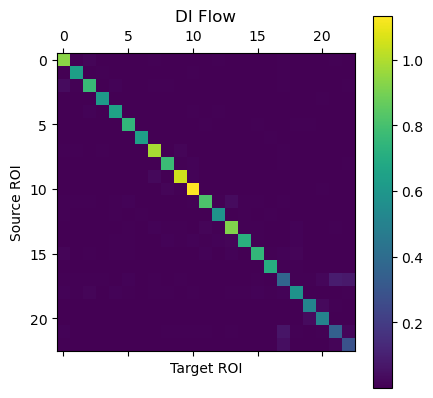

<Figure size 640x480 with 0 Axes>

In [60]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

plt.matshow(np.abs(DI_flow) )
plt.colorbar()
plt.title("DI Flow")
plt.xlabel("Target ROI")
plt.ylabel("Source ROI")
plt.show()

fig = plt.gcf()
Path("saves").mkdir(exist_ok=True)

plt.savefig(Path("saves/di_flow.png"))